In [1]:
import gymnasium as gym
import numpy as np
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
import time

env = gym.make('Acrobot-v1', render_mode=None)

In [2]:
# visualizing action space and observation space
print(env.action_space)
print(env.observation_space)
print(env.observation_space.shape)

Discrete(3)
Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
(6,)


In [3]:
# with logging

class SARSA():
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=0.1, decay_rate=0.99, n_bins=10, decay=False, end_eps=0, stop_decay=False, log_dir="logs/", seed = 0):
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.decay_rate = decay_rate
        self.decay = decay
        self.end_eps = end_eps
        self.bins = n_bins
        self.n = 100 # average of last n rewards
        self.Q = {}
        self.log_dir = log_dir
        self.init_epsilon = epsilon
        self.init_alpha = alpha
        self.stop_decay = stop_decay

    def get_action(self, state):
        rand = np.random.rand()
        if rand < self.epsilon:
            return self.env.action_space.sample()
        else:
            if state not in self.Q:
                return self.env.action_space.sample()
            else:
                return np.argmax(self.Q.get(state))
    
    def bin_state(self, state):
        for i in range(len(state)):
            state[i] = int((state[i] - self.env.observation_space.low[i]) / (self.env.observation_space.high[i] - self.env.observation_space.low[i]) * self.bins)
        return tuple(state)
        
    def update(self, state, action, reward, next_state, next_action):
        # initialization of Q values
        if state not in self.Q:
            # initialize with zeros normally
            if self.seed == 0:
                self.Q[state] = np.zeros(self.env.action_space.n)
            
            # initialize with the seed (for q3)
            else:
                self.Q[state] = self.rng.uniform(-24, 0, self.env.action_space.n)
        current_q = self.Q[state][action]
        if next_state not in self.Q:
            self.Q[next_state] = np.zeros(self.env.action_space.n)
        next_q = self.Q[next_state][next_action]
        td_error = reward + self.gamma * next_q - current_q
        new_q = current_q + self.alpha * td_error
        self.Q[state][action] = new_q
        return td_error

    def train(self, timesteps=100000, n=100):
        self.n = n
        state, _ = self.env.reset()
        state = self.bin_state(state)
        action = self.get_action(state)

        episode_reward = 0
        episode = 0
        reward_history = []
        td_errors = []

        logs = {
            "step": [],
            "episode": [],
            "episode_reward": [],
            f"avg_reward_{self.n}": [],
            "avg_td_error": [],
            "epsilon": [],
            "alpha": [],
            "gamma": [],
            "q_size": []
        }

        with tqdm(total=timesteps) as pbar:
            for t in range(1, timesteps + 1):
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                next_state = self.bin_state(next_state)
                next_action = self.get_action(next_state)

                td_error = self.update(state, action, reward, next_state, next_action)
                td_errors.append(abs(td_error))

                done = terminated or truncated
                episode_reward += reward

                if done:
                    episode += 1
                    reward_history.append(episode_reward)
                    avg_reward = np.mean(reward_history[-self.n:]) if len(reward_history) >= self.n else np.mean(reward_history)
                    avg_td = np.mean(td_errors) if td_errors else 0

                    logs["step"].append(t)
                    logs["episode"].append(episode)
                    logs["episode_reward"].append(episode_reward)
                    logs[f"avg_reward_{self.n}"].append(avg_reward)
                    logs["avg_td_error"].append(avg_td)
                    logs["epsilon"].append(self.epsilon)
                    logs["alpha"].append(self.alpha)
                    logs["gamma"].append(self.gamma)
                    logs["q_size"].append(len(self.Q))

                    pbar.set_postfix({
                        "Ep": episode,
                        "Reward": episode_reward,
                        f"Avg{self.n}": round(avg_reward, 2),
                        "qtablesize": len(self.Q)
                    })

                    if self.decay:
                        self.epsilon = max(self.end_eps, self.epsilon * self.decay_rate)
                    td_errors = []
                    episode_reward = 0
                    state, _ = self.env.reset()
                    state = self.bin_state(state)
                    action = self.get_action(state)
                else:
                    state = next_state
                    action = next_action

                pbar.update(1)

        with open(f"{self.log_dir}s_qtable_{self.init_alpha}_{self.init_epsilon}.pkl", "wb") as f:
            pickle.dump(self.Q, f)  

        with open(f"{self.log_dir}s_logs_{self.init_alpha}_{self.init_epsilon}.pkl", "wb") as f:
            pickle.dump(logs, f)

    def test(self, qtable_path="logs/s_qtable.pkl", timesteps=1000):
        with open(qtable_path, "rb") as f:
            self.Q = pickle.load(f)

        state, _ = self.env.reset()
        state = self.bin_state(state)

        total_reward = 0
        episode_rewards = []
        r = 0

        for t in range(timesteps):
            action = np.argmax(self.Q.get(state, np.zeros(self.env.action_space.n)))
            next_state, reward, terminated, truncated, _ = self.env.step(action)
            next_state = self.bin_state(next_state)

            total_reward += reward
            r += reward
            done = terminated or truncated

            if done:
                episode_rewards.append(r)
                r = 0
                state, _ = self.env.reset()
                state = self.bin_state(state)
            else:
                state = next_state

        print("Total Reward:", total_reward)
        print("Episode Rewards:", episode_rewards)

In [4]:
sarsa_agent = SARSA(env)
sarsa_agent.train(timesteps=2000000, n=200)

100%|██████████| 2000000/2000000 [02:25<00:00, 13739.32it/s, Ep=5600, Reward=-294, Avg200=-290, qtablesize=8886]


In [ ]:
envtest = gym.make('Acrobot-v1', render_mode="human")
sarsa_agent = SARSA(envtest)
sarsa_agent.test(qtable_path="logs/s_qtable_0.1_0.1.pkl", timesteps=1000)

c:\Users\shand\miniconda3\envs\rl_pa1\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [ ]:
class QLearn():
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=0.1, decay_rate=0.99, decay=False, n_bins=10, end_eps=0, stop_decay=False, log_dir="logs/", seed=0):
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.decay_rate = decay_rate
        self.decay = decay
        self.end_eps = end_eps
        self.stop_decay = stop_decay
        self.bins = n_bins
        self.n = 100 # average of last n rewards
        self.Q = {}
        self.log_dir = log_dir
        self.init_epsilon = epsilon
        self.init_alpha = alpha

    def get_action(self, state):
        rand = np.random.rand()
        if rand < self.epsilon:
            return self.env.action_space.sample()
        else:
            return np.argmax(self.Q.get(state, np.zeros(self.env.action_space.n)))
    
    def bin_state(self, state):
        for i in range(len(state)):
            state[i] = int((state[i] - self.env.observation_space.low[i]) / (self.env.observation_space.high[i] - self.env.observation_space.low[i]) * self.bins)
        return tuple(state)
        
    def update(self, state, action, reward, next_state):
        if state not in self.Q:
            if self.seed == 0:
                self.Q[state] = np.zeros(self.env.action_space.n)

            else:
                self.Q[state] = self.rng.uniform(-24, 0, self.env.action_space.n) # for q3   
        current_q = self.Q[state][action]
        if next_state not in self.Q:
            self.Q[next_state] = np.zeros(self.env.action_space.n)
            action_max = self.env.action_space.sample()
        else:
            action_max = np.argmax(self.Q[next_state])
        next_q = self.Q[next_state][action_max]
        td_error = reward + self.gamma * next_q - current_q
        new_q = current_q + self.alpha * td_error
        self.Q[state][action] = new_q
        return td_error

    def train(self, timesteps=100000, n=200):
        self.n = n
        state, _ = self.env.reset()
        state = self.bin_state(state)

        episode_reward = 0
        episode = 0
        reward_history = []
        td_errors = []

        logs = {
            "step": [],
            "episode": [],
            "episode_reward": [],
            f"avg_reward_{self.n}": [],
            "avg_td_error": [],
            "epsilon": [],
            "alpha": [],
            "gamma": [],
            "q_size": []
        }

        with tqdm(total=timesteps) as pbar:
            for t in range(1, timesteps + 1):
                action = self.get_action(state)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                next_state = self.bin_state(next_state)

                td_error = self.update(state, action, reward, next_state)
                td_errors.append(abs(td_error))

                done = terminated or truncated
                episode_reward += reward

                if done:
                    episode += 1
                    reward_history.append(episode_reward)
                    avg_reward = np.mean(reward_history[-self.n:]) if len(reward_history) >= self.n else np.mean(reward_history)
                    avg_td = np.mean(td_errors) if td_errors else 0

                    logs["step"].append(t)
                    logs["episode"].append(episode)
                    logs["episode_reward"].append(episode_reward)
                    logs[f"avg_reward_{self.n}"].append(avg_reward)
                    logs["avg_td_error"].append(avg_td)
                    logs["epsilon"].append(self.epsilon)
                    logs["alpha"].append(self.alpha)
                    logs["gamma"].append(self.gamma)
                    logs["q_size"].append(len(self.Q))

                    pbar.set_postfix({
                        "Ep": episode,
                        "Reward": episode_reward,
                        f"Avg{self.n}": round(avg_reward, 2),
                        "Qsize": len(self.Q)
                    })

                    if self.decay:
                        self.epsilon = max(self.end_eps, self.epsilon * self.decay_rate)
                    td_errors = []
                    episode_reward = 0
                    state, _ = self.env.reset()
                    state = self.bin_state(state)
                    action = self.get_action(state)
                else:
                    state = next_state

                pbar.update(1)

        with open(f"{self.log_dir}q_qtable_{self.init_alpha}_{self.init_epsilon}.pkl", "wb") as f:
            pickle.dump(self.Q, f)

        with open(f"{self.log_dir}q_logs_{self.init_alpha}_{self.init_epsilon}.pkl", "wb") as f:
            pickle.dump(logs, f)

    def test(self, qtable_path="logs/q_qtable.pkl", timesteps=1000):
        with open(qtable_path, "rb") as f:
            self.Q = pickle.load(f)

        state, _ = self.env.reset()
        state = self.bin_state(state)

        total_reward = 0
        episode_rewards = []
        r = 0

        for t in range(timesteps):
            action = np.argmax(self.Q.get(state, np.zeros(self.env.action_space.n)))
            next_state, reward, terminated, truncated, _ = self.env.step(action)
            next_state = self.bin_state(next_state)

            total_reward += reward
            r += reward
            done = terminated or truncated

            if done:
                episode_rewards.append(r)
                r = 0
                state, _ = self.env.reset()
                state = self.bin_state(state)
            else:
                state = next_state

        print("Total Reward:", total_reward)
        print("Episode Rewards:", episode_rewards)

In [ ]:
q_agent = QLearn(env)
q_agent.train(timesteps=2000000)

# 2) Plotting return v/s timesteps for SARSA and Q-Learning.

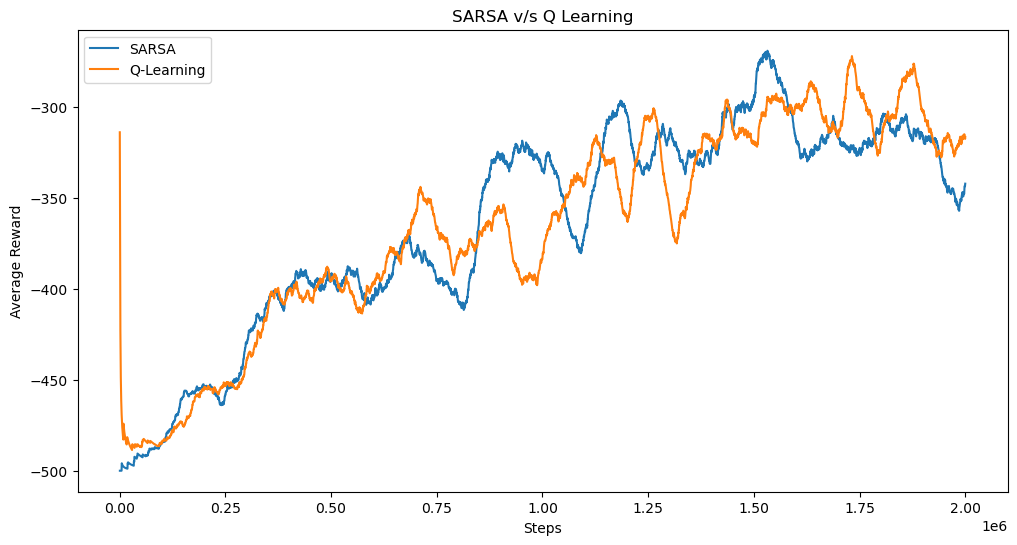

In [ ]:
# comparing sarsa and q learning avg reward over 50 episodes -
def plot_analysis(logfile, verbose):
    with open(logfile, "rb") as f:
        logs = pickle.load(f)

    return logs["episode_reward"], logs["avg_reward_200"], logs["episode"], logs["step"]

_, s_ep_rew,_, s_steps = plot_analysis("logs/s_logs_0.1_0.1.pkl", False)
_, q_ep_rew, _, q_steps = plot_analysis("logs/q_logs_0.1_0.1.pkl", False)

plt.figure(figsize=(12, 6))
plt.plot(s_steps, s_ep_rew, label="SARSA")
plt.plot(q_steps, q_ep_rew, label="Q-Learning")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("SARSA v/s Q Learning")
plt.legend()

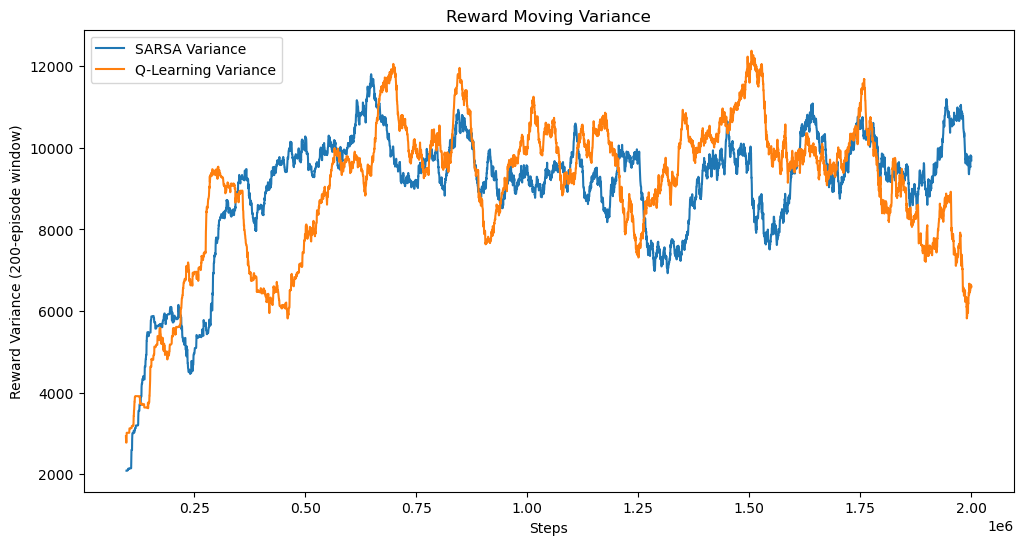

In [ ]:
# comparing variance

ep_rew_s, _, _, s_steps = plot_analysis("logs/s_logs_0.1_0.1.pkl", False)
ep_rew_q, _, _, q_steps = plot_analysis("logs/q_logs_0.1_0.1.pkl", False)

def rolling_variance(data, window=200):
    data = np.array(data)
    variances = []
    for i in range(len(data)):
        if i < window:
            variances.append(np.nan)  # not enough data yet
        else:
            variances.append(np.var(data[i-window:i], ddof=1))
    return np.array(variances)

sarsa_variance = rolling_variance(ep_rew_s)
q_variance = rolling_variance(ep_rew_q)
plt.figure(figsize=(12, 6))
plt.plot(s_steps, sarsa_variance, label="SARSA Variance")
plt.plot(q_steps, q_variance, label="Q-Learning Variance")
plt.xlabel("Steps")
plt.ylabel("Reward Variance (200-episode window)")
plt.title("Reward Moving Variance")
plt.legend()
plt.show()

# 2 a) Tuning Hyperparameters (stepsize and epsilon)

In [ ]:
alpha_values = [0.01, 0.05, 0.1, 0.3, 0.5]
epsilon_values = [0.01, 0.05, 0.1, 0.2, 0.3]

gamma = 0.99

print(f"Alpha values: {alpha_values}")
print(f"Epsilon values: {epsilon_values}")

Alpha values: [0.01, 0.05, 0.1, 0.3, 0.5]
Epsilon values: [0.01, 0.05, 0.1, 0.2, 0.3]


In [ ]:
def hyperparameter_sweep(env, algorithm_class, algo, alpha_values, epsilon_values, gamma=0.99, timesteps=2000000, n=200):  
      
    results = {
        'hyperparameters': [],
        'final_avg_rewards': [],
        'final_q_sizes': [],
        'training_times': [],
        'log_files': []
    }
    
    
    # print(f"\n{'='*80}")
    print(f"Starting Hyperparameter Sweep for {algo.upper()}")
    print(f"Timesteps per run: {timesteps}")
    # print(f"{'='*80}\n")
    
    for alpha in alpha_values:
        for epsilon in epsilon_values:
            print(f"\nTraining with alpha={alpha}, epsilon={epsilon}")
            print("-" * 60)
            
            agent = algorithm_class(env, alpha=alpha, gamma=gamma, epsilon=epsilon)
            
            start_time = time.time()
            agent.train(timesteps=timesteps, n=n)
            training_time = time.time() - start_time
            
            log_file = f"logs/{algo}_logs_{agent.alpha}_{agent.epsilon}.pkl"
            with open(log_file, "rb") as f:
                logs = pickle.load(f)
            
            # Get final metrics
            final_avg_reward = logs[f'avg_reward_{n}'][-1] if logs[f'avg_reward_{n}'] else None
            final_q_size = logs['q_size'][-1] if logs['q_size'] else None
            
            # Store results
            results['hyperparameters'].append({'alpha': alpha, 'epsilon': epsilon, 'gamma': gamma})
            results['final_avg_rewards'].append(final_avg_reward)
            results['final_q_sizes'].append(final_q_size)
            results['training_times'].append(training_time)
            
            print(f"Completed in {training_time:.1f}s | Final Avg Reward: {final_avg_reward:.2f} | Q-table size: {final_q_size}")
    
    # Save overall results
    results_file = f"{algo}_hyperparameter_results_{timesteps}.pkl"
    with open(results_file, "wb") as f:
        pickle.dump(results, f)
    
    print(f"\n{'='*80}")
    print(f"Hyperparameter Sweep Complete!")
    print(f"Results saved to: {results_file}")
    print(f"{'='*80}\n")
    
    # Print summary
    best_idx = np.argmax(results['final_avg_rewards'])
    print("Summary:")
    print(f"Best hyperparameters: {results['hyperparameters'][best_idx]}")
    print(f"Best final avg reward: {results['final_avg_rewards'][best_idx]:.2f}")
    print(f"Total training time: {sum(results['training_times']):.1f}s ({sum(results['training_times'])/60:.1f} minutes)")
    
    env.close()
    return results

In [ ]:
sarsa_results = hyperparameter_sweep(
    env=env,
    algorithm_class=SARSA,
    algo="s",
    alpha_values=alpha_values,
    epsilon_values=epsilon_values,
    gamma=0.99,
    n=200,
    timesteps=2000000
)

In [ ]:
q_hyp_results = hyperparameter_sweep(
    env=env,
    algorithm_class=QLearn,
    algo="q",
    alpha_values=alpha_values,
    epsilon_values=epsilon_values,
    gamma=0.99,
    n=200,
    timesteps=2000000
)

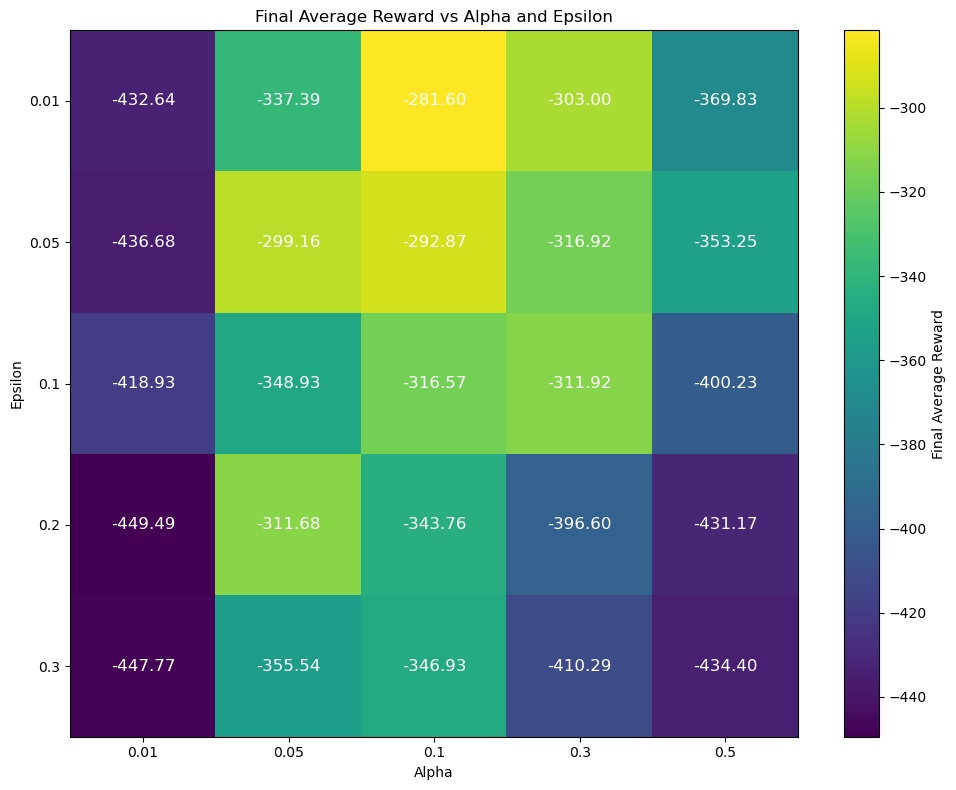

In [ ]:
# plotting performance over hyperparameters in terms of final average reward
# also checking which hyperparameters explore more

with open("q_hyperparameter_results_2000000.pkl", "rb") as f:
    results = pickle.load(f)

hyperparameters = results['hyperparameters']
final_avg_rewards = results['final_avg_rewards']

reward_matrix = np.zeros((len(epsilon_values), len(alpha_values)))

for i, hp in enumerate(hyperparameters):
    alpha_idx = alpha_values.index(hp['alpha'])
    epsilon_idx = epsilon_values.index(hp['epsilon'])
    reward_matrix[epsilon_idx, alpha_idx] = final_avg_rewards[i]

plt.figure(figsize=(10, 8))
plt.imshow(reward_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Final Average Reward')

# Set axis labels
plt.xticks(range(len(alpha_values)), alpha_values)
plt.yticks(range(len(epsilon_values)), epsilon_values)
plt.xlabel('Alpha') #, fontsize=12)
plt.ylabel('Epsilon') #, fontsize=12)
plt.title('Final Average Reward vs Alpha and Epsilon') #, fontsize=14)

# Add text annotations
for i in range(len(epsilon_values)):
    for j in range(len(alpha_values)):
        plt.text(j, i, f'{reward_matrix[i, j]:.2f}',
                ha='center', va='center', color='white', fontsize=12)

plt.tight_layout()
plt.show()

# Implementing Epsilon-Decay

In [ ]:
decay_sarsa = SARSA(env, epsilon=0.05, alpha=0.1, decay=True, decay_rate=0.9995, log_dir="decay_logs/")
decay_sarsa.train(timesteps=2000000, n=200)

In [ ]:
decay_q = QLearn(env, epsilon=0.01, alpha=0.1, decay=True, decay_rate=0.9995, log_dir="decay_logs/")
decay_q.train(timesteps=2000000, n=200)

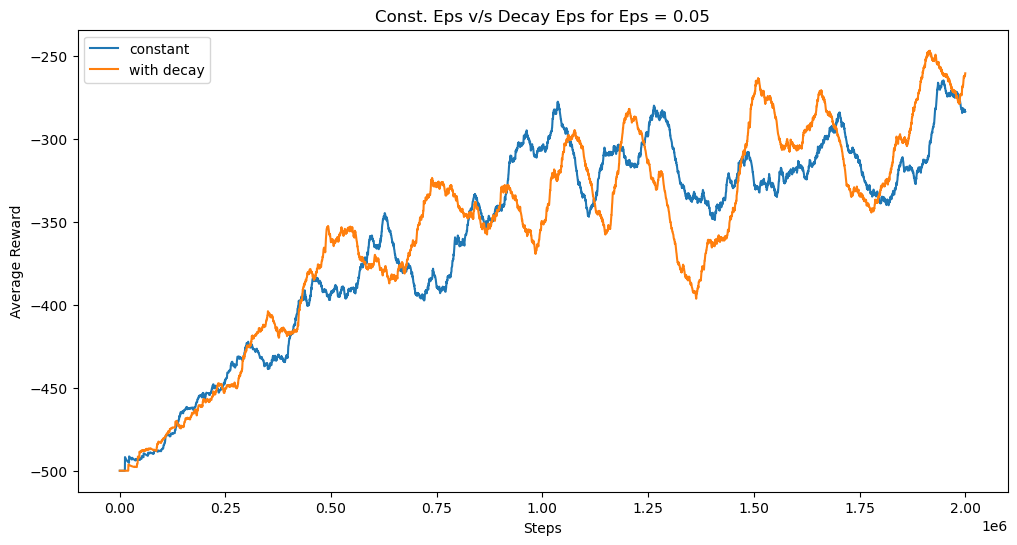

In [ ]:
_, s_ep_rew, _, s_steps = plot_analysis("logs/s_logs_0.1_0.05.pkl", False)
_, s_dec_ep_rew, _, s_steps2 = plot_analysis("decay_logs/s_logs_0.1_0.05.pkl", False)

plt.figure(figsize=(12, 6))
plt.plot(s_steps, s_ep_rew, label="constant")
plt.plot(s_steps2, s_dec_ep_rew, label="with decay")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Const. Eps v/s Decay Eps for Eps = 0.05")
plt.legend()

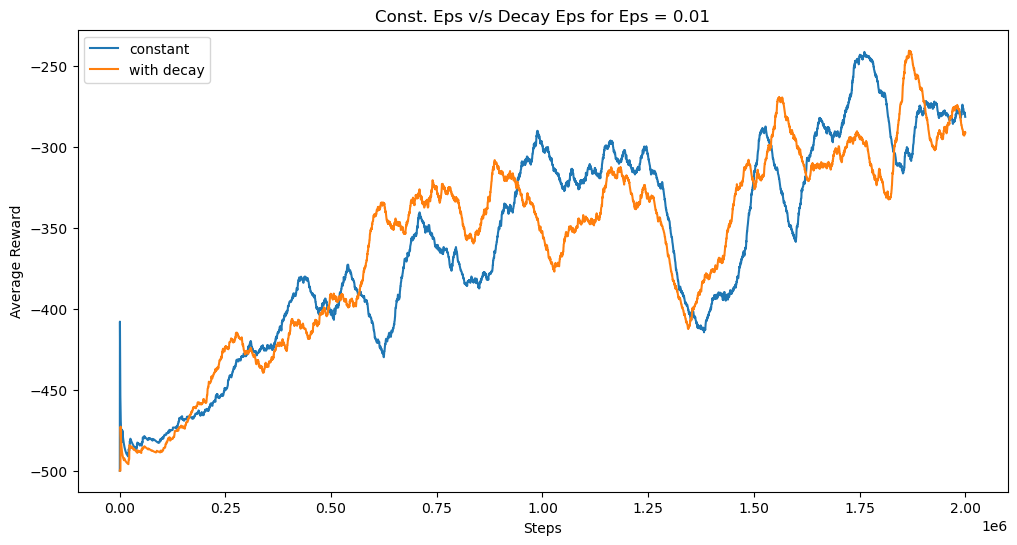

In [ ]:
_, q_ep_rew, _, q_steps = plot_analysis("logs/q_logs_0.1_0.01.pkl", False)
_, s_dec_ep_rew, _, s_steps2 = plot_analysis("decay_logs/q_logs_0.1_0.01.pkl", False)

plt.figure(figsize=(12, 6))
plt.plot(q_steps, q_ep_rew, label="constant")
plt.plot(s_steps2, s_dec_ep_rew, label="with decay")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Const. Eps v/s Decay Eps for Eps = 0.01")
plt.legend()

# 2 b) Training with 10 different seeds for the best hyperparameters.

In [ ]:
import os
for seed in range(100, 111):
    print(f"Seed: {seed}")
    sarsa_agent = SARSA(env, alpha=0.1, epsilon=0.05, decay=True, decay_rate=0.9995, n_bins=10, log_dir="seed_logs/", seed=seed)
    sarsa_agent.train(timesteps=2000000, n=200)
    os.rename('seed_logs/s_logs_0.1_0.05.pkl', f'seed_logs/s_{seed}.pkl')
    os.rename('seed_logs/s_qtable_0.1_0.05.pkl', f'seed_logs/s_{seed}_qtable.pkl')

    q_agent = QLearn(env, alpha=0.1, epsilon=0.01, decay=True, decay_rate=0.9995, n_bins=10, log_dir="seed_logs/", seed=seed)
    q_agent.train(timesteps=2000000, n=200)
    os.rename('seed_logs/q_logs_0.1_0.01.pkl', f'seed_logs/q_{seed}.pkl')
    os.rename('seed_logs/q_qtable_0.1_0.01.pkl', f'seed_logs/q_{seed}_qtable.pkl')

Seed: 100


100%|██████████| 2000000/2000000 [01:10<00:00, 28299.43it/s, Ep=5795, Reward=-198, Avg200=-306, Qsize=9088]


Seed: 101


100%|██████████| 2000000/2000000 [01:10<00:00, 28353.02it/s, Ep=5824, Reward=-220, Avg200=-261, Qsize=9223]


Seed: 102


...

100%|██████████| 2000000/2000000 [01:06<00:00, 30205.79it/s, Ep=5949, Reward=-198, Avg200=-276, Qsize=9232]


Seed: 109


100%|██████████| 2000000/2000000 [01:05<00:00, 30315.74it/s, Ep=5855, Reward=-318, Avg200=-294, Qsize=9104]


Seed: 110


100%|██████████| 2000000/2000000 [01:08<00:00, 29209.98it/s, Ep=5840, Reward=-245, Avg200=-293, Qsize=9077]


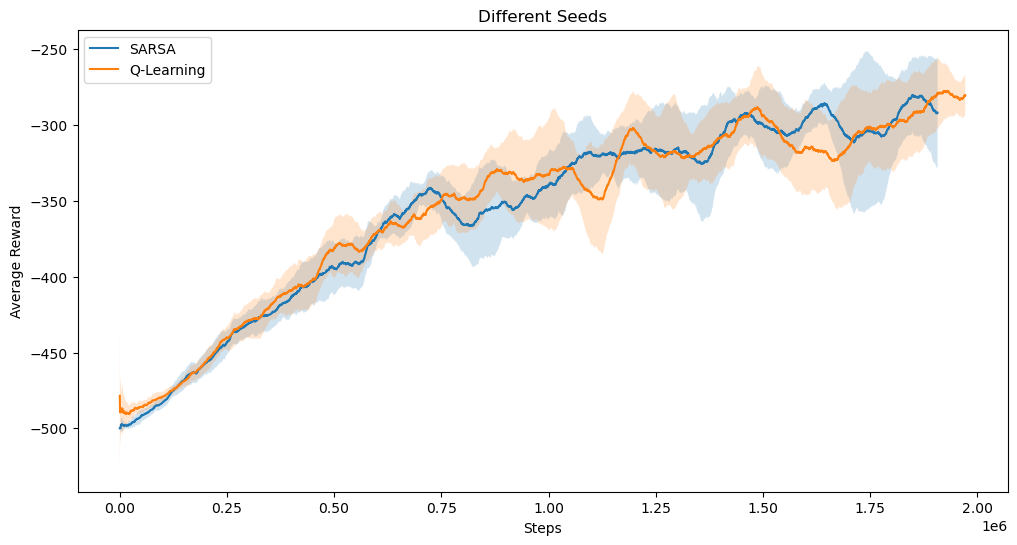

In [ ]:
# comparing sarsa and q-learning plots
plt.figure(figsize=(12, 6))

rewards1 = []
for seed in range(100, 111):
    _, s_ep_rew, _, s_steps = plot_analysis(f"seed_logs/s_{seed}.pkl", False)
    rewards1.append(s_ep_rew)

# making each reward list same length
min_len1 = min(len(r) for r in rewards1)
rewards1 = [r[:min_len1] for r in rewards1]

mean1 = np.mean(rewards1, axis=0)
std1 = np.std(rewards1, axis=0)
plt.plot(s_steps[:min_len1], mean1, label="SARSA")
plt.fill_between(s_steps[:min_len1], mean1 - std1, mean1 + std1, alpha=0.2)

rewards2 = []
for seed in range(100, 111):
    _, q_ep_rew, _, q_steps = plot_analysis(f"seed_logs/q_{seed}.pkl", False)
    rewards2.append(q_ep_rew)

min_len2 = min(len(r) for r in rewards2)
rewards2 = [r[:min_len2] for r in rewards2]

mean2 = np.mean(rewards2, axis=0)
std2 = np.std(rewards2, axis=0)
plt.plot(q_steps[:min_len2], mean2, label="Q-Learning")
plt.fill_between(q_steps[:min_len2], mean2 - std2, mean2 + std2, alpha=0.2)

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Different Seeds")
plt.legend()

# 3) Running SARSA and Q-Learning with Epsilon decaying from 1 to 0.1

In [ ]:
sarsa3 = SARSA(env, alpha=0.1, epsilon=1.0 , decay=True, stop_decay=True, end_eps=0.1, log_dir="c/")
sarsa3.train(timesteps=2000000, n=200)

q3 = QLearn(env, alpha=0.1, epsilon=1.0 , decay=True, stop_decay=True, end_eps=0.1, log_dir="c/")
q3.train(timesteps=2000000, n=200)

In [ ]:
def test(qtable_path="c/s_qtable_0.1_1.0.pkl", timesteps=2000000, n=200, algo="s", agent=None):
    with open(qtable_path, "rb") as f:
        Q = pickle.load(f)

    state, _ = envtest.reset()
    state = agent.bin_state(state)

    total_reward = 0
    episode_rewards = []
    r = 0
    episode = 0
    
    test_logs = {
        "step": [],
        "episode": [],
        "episode_reward": [],
        "total_reward": [],
        "q_size": [],
        f"avg_reward_{n}": [],
    }

    for t in range(timesteps):
        action = np.argmax(Q.get(state, np.zeros(envtest.action_space.n)))
        next_state, reward, terminated, truncated, _ = envtest.step(action)
        next_state = agent.bin_state(next_state)

        total_reward += reward
        r += reward
        done = terminated or truncated

        if done:
            episode += 1
            episode_rewards.append(r)
            avg_reward = np.mean(episode_rewards[-n:]) if len(episode_rewards) >= n else np.mean(episode_rewards)
            
            test_logs["step"].append(t)
            test_logs["episode"].append(episode)
            test_logs["episode_reward"].append(r)
            test_logs["total_reward"].append(total_reward)
            test_logs[f"avg_reward_{n}"].append(avg_reward)
            test_logs["q_size"].append(len(Q))
            
            r = 0
            state, _ = envtest.reset()
            state = agent.bin_state(state)
        else:
            state = next_state

    print("Total Reward:", total_reward)
    print("Episode Rewards:", episode_rewards)
    print("Average Episode Reward:", np.mean(episode_rewards))
    print("Number of Episodes:", episode)
    
    # Save test logs
    if algo=="s":
        with open(f"c/s_test_logs_{agent.init_alpha}_{agent.init_epsilon}.pkl", "wb") as f:
            pickle.dump(test_logs, f)
    elif algo=="q":
        with open(f"c/q_test_logs_{agent.init_alpha}_{agent.init_epsilon}.pkl", "wb") as f:
            pickle.dump(test_logs, f)
    
    return test_logs

In [ ]:
# envtest = gym.make('Acrobot-v1', render_mode=None)
# sarsa3 = SARSA(envtest, epsilon=1.0, alpha=0.1, decay=True, stop_decay=True, end_eps=0.1, log_dir="c/")
# q3 = QLearn(envtest, epsilon=1.0, alpha=0.1, decay=True, stop_decay=True, end_eps=0.1, log_dir="c/")

test_logs_sarsa = test(qtable_path="c/s_qtable_0.1_1.0.pkl", timesteps=2000000, algo="s", agent=sarsa3)
test_logs_q = test(qtable_path="c/q_qtable_0.1_1.0.pkl", timesteps=2000000, algo="q", agent=q3)

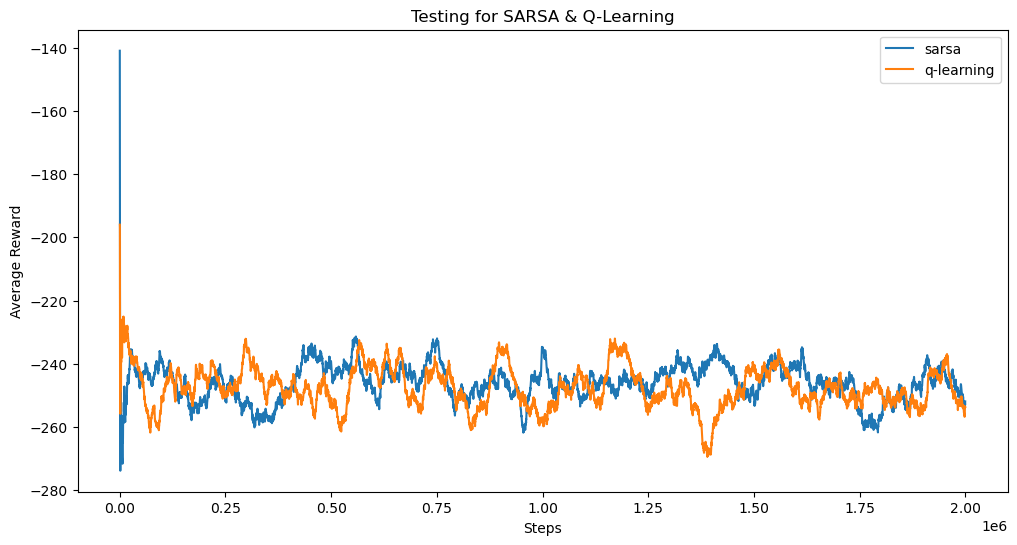

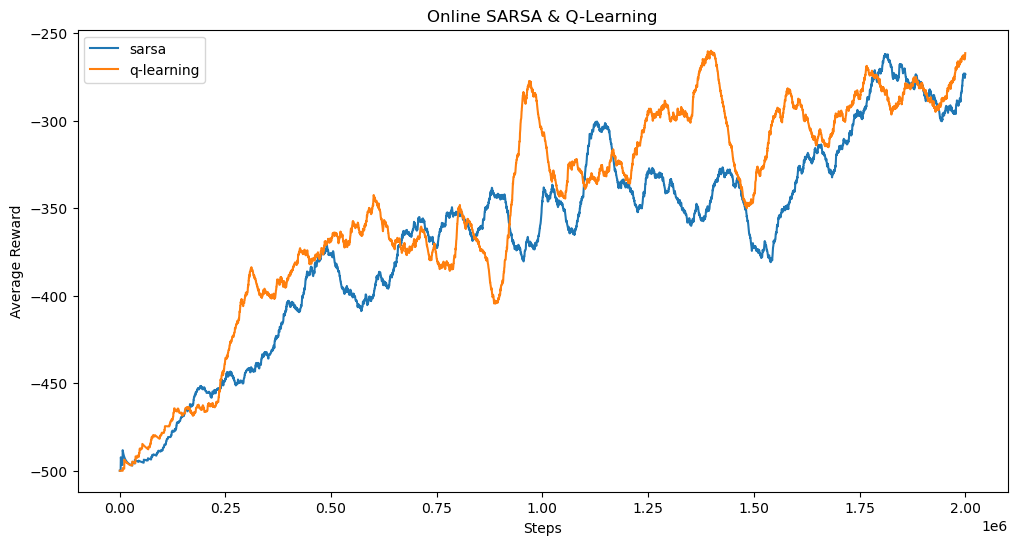

In [ ]:
_, s_test_rew, _,  s_test_steps = plot_analysis("c/s_test_logs_0.1_1.0.pkl", False)
_, s_online_rew, _, s_online_steps2 = plot_analysis("c/s_logs_0.1_1.0.pkl", False)
_, q_test_rew, _, q_test_steps = plot_analysis("c/q_test_logs_0.1_1.0.pkl", False)
_, q_online_rew, _, q_online_steps2 = plot_analysis("c/q_logs_0.1_1.0.pkl", False)

plt.figure(figsize=(12, 6))
plt.plot(s_test_steps, s_test_rew, label="sarsa")
plt.plot(q_test_steps, q_test_rew, label="q-learning")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Testing for SARSA & Q-Learning")
plt.legend()

plt.figure(figsize=(12, 6))
plt.plot(s_online_steps2, s_online_rew, label="sarsa")
plt.plot(q_online_steps2, q_online_rew, label="q-learning")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Online SARSA & Q-Learning")
plt.legend()

In [ ]:
print(s_online_rew[-1])
print(q_online_rew[-1])

-273.415
-261.415


100%|██████████| 2000000/2000000 [00:59<00:00, 33891.07it/s, Ep=4006, Reward=-500, Avg200=-499, qtablesize=4860]


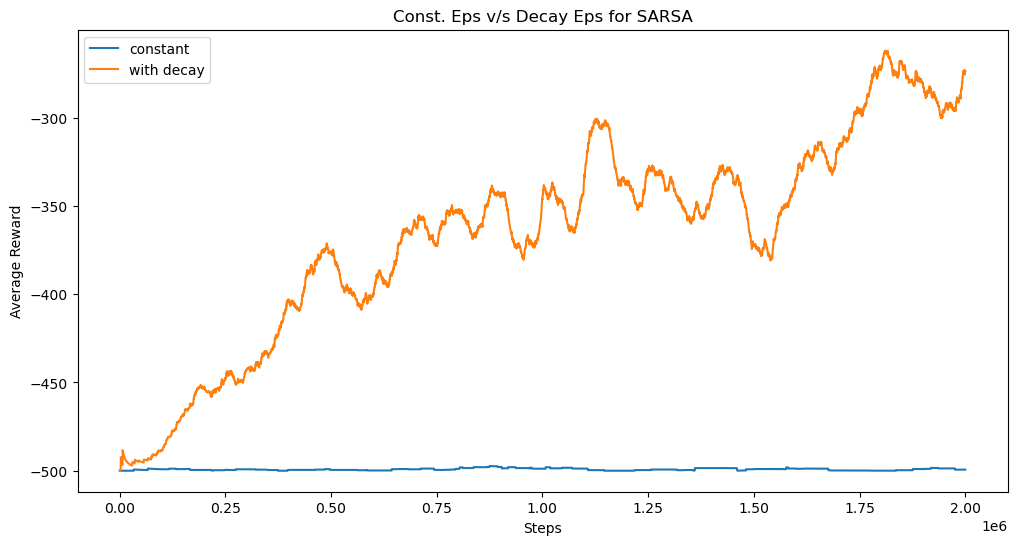

In [ ]:
# comparing the decay with constant epsilon
sarsa_1 = SARSA(env, alpha=0.1, epsilon=1.0 , decay=False, log_dir="logs/")
sarsa_1.train(timesteps=2000000, n=200)
_, s_ep_rew, _, s_steps = plot_analysis("logs/s_logs_0.1_1.0.pkl", False)
_, s_dec_ep_rew, _, s_steps2 = plot_analysis("c/s_logs_0.1_1.0.pkl", False)

plt.figure(figsize=(12, 6))
plt.plot(s_steps, s_ep_rew, label="constant")
plt.plot(s_steps2, s_dec_ep_rew, label="with decay")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Const. Eps v/s Decay Eps for SARSA")
plt.legend()

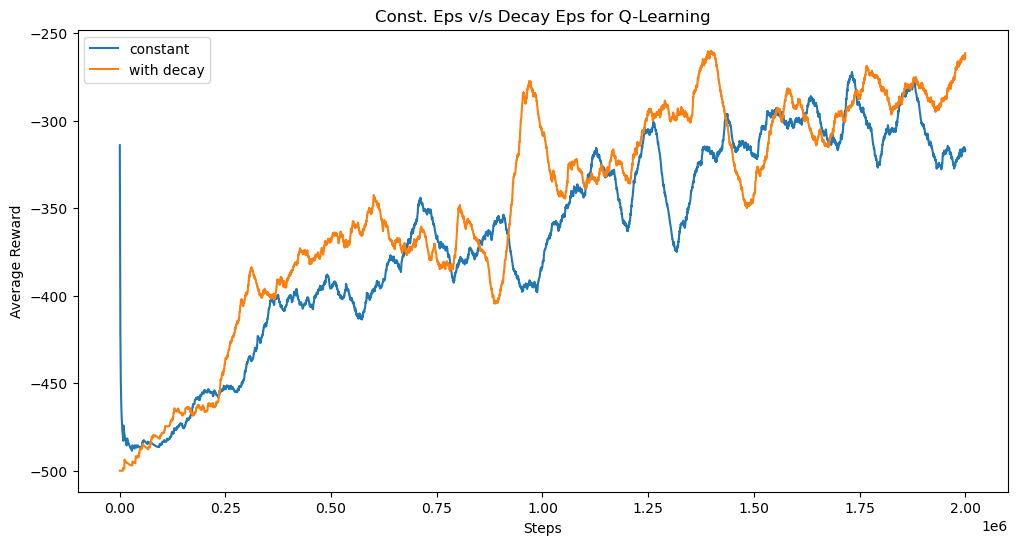

In [ ]:
# comparing the decay with constant epsilon
_, s_ep_rew, _, s_steps = plot_analysis("logs/q_logs_0.1_0.1.pkl", False)
_, s_dec_ep_rew, _, s_steps2 = plot_analysis("c/q_logs_0.1_1.0.pkl", False)

plt.figure(figsize=(12, 6))
plt.plot(s_steps, s_ep_rew, label="constant")
plt.plot(s_steps2, s_dec_ep_rew, label="with decay")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Const. Eps v/s Decay Eps for Q-Learning")
plt.legend()

# 4) Testing with various number of bins for the tuned hyperparameters.

In [ ]:
for bin in [5, 10, 15, 20]:
    print(f"Bins: {bin}")
    sarsa_agent = SARSA(env, alpha=0.1, epsilon=0.05, decay=True, n_bins=bin, decay_rate=0.9995, log_dir="bins_logs/")
    sarsa_agent.train(timesteps=2000000, n=200)
    q_agent = QLearn(env, alpha=0.1, epsilon=0.01, decay=False, n_bins=bin, log_dir="bins_logs/")
    q_agent.train(timesteps=2000000, n=200)
    os.rename('bins_logs/s_logs_0.1_0.05.pkl', f'bins_logs/s_bins_{bin}.pkl')
    os.rename('bins_logs/s_qtable_0.1_0.05.pkl', f'bins_logs/s_bins_{bin}_qtable.pkl')
    os.rename('bins_logs/q_logs_0.1_0.01.pkl', f'bins_logs/q_bins_{bin}.pkl')
    os.rename('bins_logs/q_qtable_0.1_0.01.pkl', f'bins_logs/q_bins_{bin}_qtable.pkl')

Bins: 5


100%|██████████| 2000000/2000000 [01:11<00:00, 28116.19it/s, Ep=4868, Reward=-259, Avg200=-381, Qsize=1539]


Bins: 10


100%|██████████| 2000000/2000000 [01:12<00:00, 27686.05it/s, Ep=5947, Reward=-433, Avg200=-256, Qsize=9128]


Bins: 15


100%|██████████| 2000000/2000000 [01:16<00:00, 26043.25it/s, Ep=4697, Reward=-294, Avg200=-397, Qsize=43843]


Bins: 20


100%|██████████| 2000000/2000000 [01:13<00:00, 27099.30it/s, Ep=4348, Reward=-400, Avg200=-439, Qsize=83393]


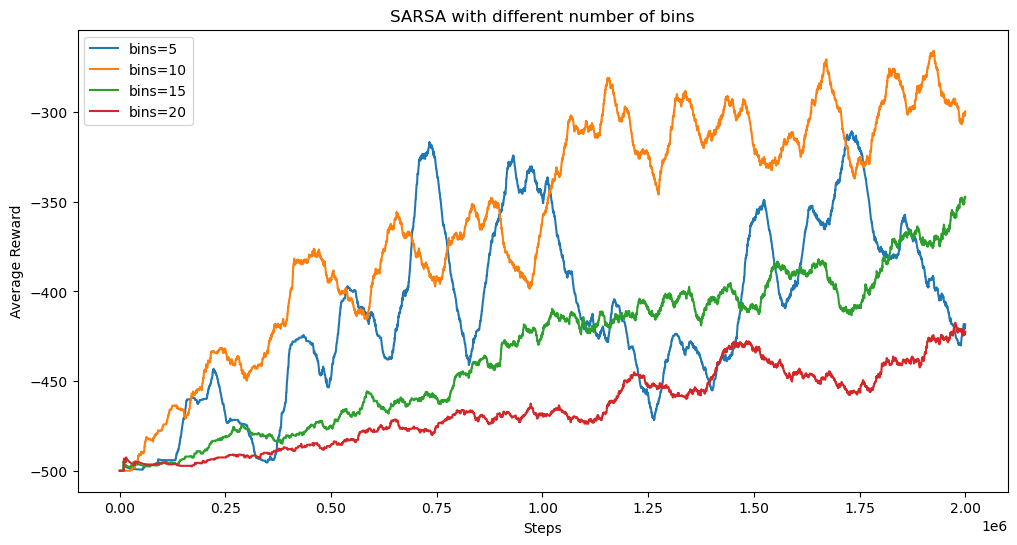

In [ ]:
_, rew_5, _, steps_5 = plot_analysis("bins_logs/s_bins_5.pkl", False)
_, rew_10, _, steps_10 = plot_analysis("bins_logs/s_bins_10.pkl", False)
_, rew_15, _, steps_15 = plot_analysis("bins_logs/s_bins_15.pkl", False)
_, rew_20, _, steps_20 = plot_analysis("bins_logs/s_bins_20.pkl", False)

plt.figure(figsize=(12, 6))
plt.plot(steps_5, rew_5, label="bins=5")
plt.plot(steps_10, rew_10, label="bins=10")
plt.plot(steps_15, rew_15, label="bins=15")
plt.plot(steps_20, rew_20, label="bins=20")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("SARSA with different number of bins")

plt.legend()

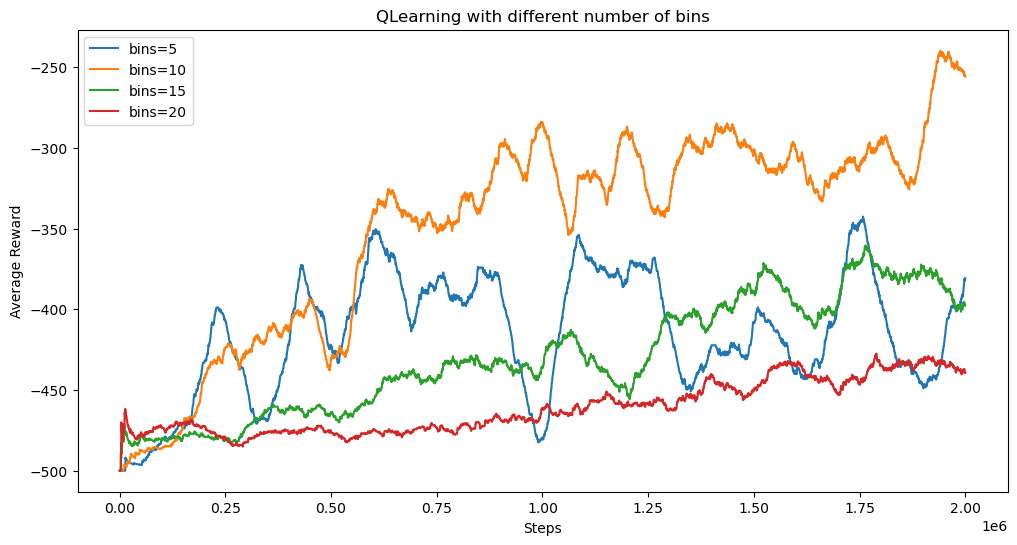

In [ ]:
_, rew_5, _, steps_5 = plot_analysis("bins_logs/q_bins_5.pkl", False)
_, rew_10, _, steps_10 = plot_analysis("bins_logs/q_bins_10.pkl", False)
_, rew_15, _, steps_15 = plot_analysis("bins_logs/q_bins_15.pkl", False)
_, rew_20, _, steps_20 = plot_analysis("bins_logs/q_bins_20.pkl", False)

plt.figure(figsize=(12, 6))
plt.plot(steps_5, rew_5, label="bins=5")
plt.plot(steps_10, rew_10, label="bins=10")
plt.plot(steps_15, rew_15, label="bins=15")
plt.plot(steps_20, rew_20, label="bins=20")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("QLearning with different number of bins")

plt.legend()

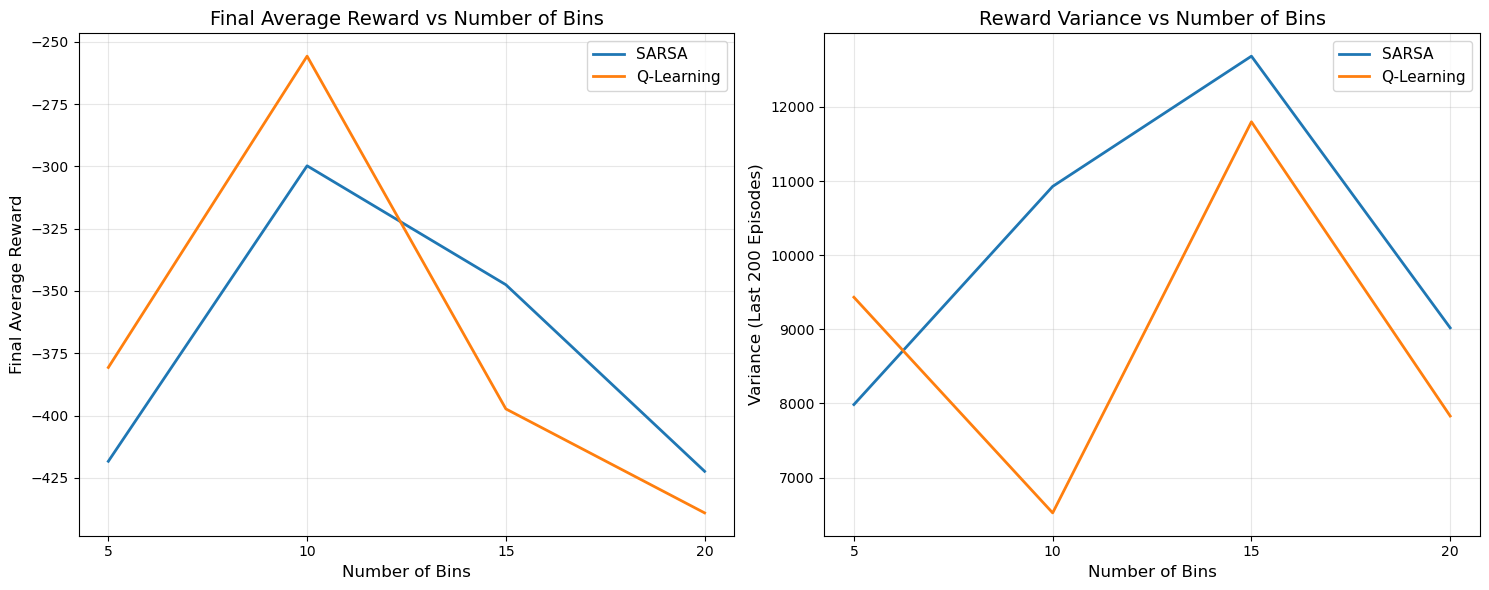


Bins       SARSA Reward         Q-Learn Reward      
5          -418.37              -380.70             
10         -299.75              -255.73             
15         -347.49              -397.34             
20         -422.40              -439.08             

Bins       SARSA Variance       Q-Learn Variance    
5          7984.90              9432.41             
10         10927.24             6524.08             
15         12683.79             11798.48            
20         9019.80              7830.48             


In [ ]:
bin_sizes = [5, 10, 15, 20]
sarsa_final_rewards = []
q_final_rewards = []
sarsa_variances = []
q_variances = []

for bin in bin_sizes:
    s_ep_rew, s_rew, _, _ = plot_analysis(f"bins_logs/s_bins_{bin}.pkl", False)
    sarsa_final_rewards.append(s_rew[-1])
    sarsa_variances.append(rolling_variance(s_ep_rew)[-1])
    
    q_ep_rew, q_rew, _, _ = plot_analysis(f"bins_logs/q_bins_{bin}.pkl", False)
    q_final_rewards.append(q_rew[-1])
    q_variances.append(rolling_variance(q_ep_rew)[-1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# final avg reward
ax1.plot(bin_sizes, sarsa_final_rewards, linewidth=2, markersize=8, label='SARSA')
ax1.plot(bin_sizes, q_final_rewards, linewidth=2, markersize=8, label='Q-Learning')
ax1.set_xlabel('Number of Bins', fontsize=12)
ax1.set_ylabel('Final Average Reward', fontsize=12)
ax1.set_title('Final Average Reward vs Number of Bins', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)
ax1.set_xticks(bin_sizes)

# for bin in bin_sizes:
#     ep_rew, _, _, _ = plot_analysis(f"bins_logs/s_bins_{bin}.pkl", False)
#     sarsa_variances.append(np.var(ep_rew[-200:]))
    
#     ep_rew, _, _, _ = plot_analysis(f"bins_logs/q_bins_{bin}.pkl", False)
#     q_variances.append(np.var(ep_rew[-200:]))

# variance
ax2.plot(bin_sizes, sarsa_variances, linewidth=2, markersize=8, label='SARSA')
ax2.plot(bin_sizes, q_variances, linewidth=2, markersize=8, label='Q-Learning')
ax2.set_xlabel('Number of Bins', fontsize=12)
ax2.set_ylabel('Variance (Last 200 Episodes)', fontsize=12)
ax2.set_title('Reward Variance vs Number of Bins', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)
ax2.set_xticks(bin_sizes)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*70)
print(f"{'Bins':<10} {'SARSA Reward':<20} {'Q-Learn Reward':<20}")
print("="*70)
for i, bin in enumerate(bin_sizes):
    print(f"{bin:<10} {sarsa_final_rewards[i]:<20.2f} {q_final_rewards[i]:<20.2f}")
print("="*70)

print("\n" + "="*70)
print(f"{'Bins':<10} {'SARSA Variance':<20} {'Q-Learn Variance':<20}")
print("="*70)
for i, bin in enumerate(bin_sizes):
    print(f"{bin:<10} {sarsa_variances[i]:<20.2f} {q_variances[i]:<20.2f}")
print("="*70)